## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026
## Project Checkpoint 2: Research Question Formation (MusicMining)

**Author:** Bryan Michael Ramos

**UIN:** 730001788

**Date:** March 17, 2026

**GitHub:** [https://github.com/bmr-ramos/CSCE676-MusicMining](https://github.com/bmr-ramos/CSCE676-MusicMining)

---

## Table of Contents
1. [Setup & Imports](#setup)
2. [Section A — Project Scope Recap](#scope)
3. [Section B — Data Loading & Preprocessing](#data-loading)
4. [Section C — Additional EDA for RQ Motivation](#additional-eda)
    - [Section C.1 — Sequential Structure Analysis](#c-1)
    - [Section C.2 — Support Threshold Sensitivity](#c-2)
    - [Section C.3 — Co-Occurrence Graph Community Preview](#c-3)
    - [Section C.4 — Comparing Ordered vs Unordered Patterns](#c-4)
5. [Section D — Research Question Definition](#rq-definition)
6. [Section E — RQ-to-Method Mapping](#rq-mapping)
7. [Section F — Motivation and Feasibility](#motivation)
    - [Section F.1 — Motivation](#motivation)
    - [Section F.2 — Non-Triviality](#motivation)
    - [Section F.3 — Feasibility](#motivation)
    - [Section F.4 — Risks and Mitigations](#motivation)
8. [Section G — Methodological Planning](#methodology)
    - [Section G.1 — Analysis Pipeline](#g-1)
    - [Section G.2 — Course Algorithms](#g-2)
    - [Section G.3 — Beyond-Course Algorithm](#g-3)
    - [Section G.4 — Evaluation Plan](#g-4)
    - [Section G.5 — Baselines](#g-5)
9. [Section H — Initial Method Feasibility Runs](#feasibility-run)
    - [Section H.1 — Feasibility Run: FP-Growth + Association Rules (RQ1 — Community Characterization)](#h-1)
    - [Section H.2 — Feasibility Run: Louvain + PageRank (RQ2 — Centerpiece: Community Detection)](#h-2)
    - [Section H.3 — Feasibility Run: PrefixSpan Sequential Pattern Mining (RQ3 — Temporal Dynamics)](#h-3)
    - [Section H.4 — Feasibility Summary](#h-4)
10. [Collaboration Declaration](#collaboration)

<a id="setup"></a>

---
## 1. Setup & Imports

I import all libraries needed for this checkpoint, including new packages for frequent itemset mining (`mlxtend`), sequential pattern mining (`prefixspan`), and community detection (`python-louvain`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
from itertools import combinations
import warnings

# New packages for Checkpoint 2 methods
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules
from prefixspan import PrefixSpan
import community as community_louvain  # python-louvain

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully.")
print(f"pandas {pd.__version__}, numpy {np.__version__}, networkx {nx.__version__}")

All libraries imported successfully.
pandas 2.3.3, numpy 2.3.5, networkx 3.6.1


<a id="scope"></a>

---
## Section A - Project Scope Recap

### Dataset
**Last.fm 1K** (Celma, 2010) — 19.15M timestamped listening events from 992 users, with user demographic profiles (gender, age, country). The data was sourced from [ocelma.net](http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html).

### Key EDA Findings (Checkpoint 1)

| Finding | Detail | Implication |
|---|---|---|
| **Power-law popularity** | Top 1% of artists account for ~48% of events | Low support thresholds needed for itemset mining |
| **Session structure** | Median 3 unique artists/session; 68% have 2+ artists | Sessions serve as natural transaction baskets |
| **High sparsity** | 98.2% user-artist matrix sparsity | Artist-level (not track-level) baskets preferred |
| **Community structure** | Co-occurrence graph shows artist clusters | Graph mining (Louvain, PageRank) is well-motivated |
| **Temporal patterns** | Evening peaks, weekday > weekend | Sequential/temporal mining can exploit ordering |
| **Demographics** | 61% male, median age 24, US/UK-dominated | Demographic stratification possible but biased |

### Planned Techniques

All techniques serve the overarching investigation of artist community structure:

| Technique | Role | Category |
|---|---|---|
| Community Detection (Louvain) | **Centerpiece** — identify artist communities | Course |
| PageRank Centrality | Identify cross-community bridge artists | Course |
| Frequent Itemset Mining (FP-Growth) | Characterize within-community co-listening | Course |
| Association Rule Mining (Apriori) | Validate FP-Growth; extract interpretable rules | Course |
| Sequential Pattern Mining (PrefixSpan) | Reveal temporal dynamics across communities | Beyond-Course |

<a id="data-loading"></a>

---
## Section B - Data Loading & Preprocessing

I reload the Last.fm 1K dataset and repeat the session segmentation from Checkpoint 1. I use the same 150-user sample and 30-minute session gap threshold established in EDA, ensuring consistency between checkpoints.

In [2]:
# ============================================================
# LOAD LAST.FM 1K DATASET
# Same loading procedure as Checkpoint 1 for consistency.
# ============================================================

DATA_DIR = '../Checkpoint 1/lastfm-dataset-1K'

print("Loading listening events...")
df = pd.read_csv(
    f'{DATA_DIR}/userid-timestamp-artid-artname-traid-traname.tsv',
    sep='\t',
    header=None,
    names=['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name'],
    on_bad_lines='skip'
)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

profiles = pd.read_csv(
    f'{DATA_DIR}/userid-profile.tsv',
    sep='\t',
    header=None,
    names=['user_id', 'gender', 'age', 'country', 'signup']
)
profiles['gender'] = profiles['gender'].fillna('')
profiles['country'] = profiles['country'].fillna('')

print(f"Full dataset: {len(df):,} events, {df['user_id'].nunique()} users")

# --- Sample 150 users (same seed as Checkpoint 1) ---
np.random.seed(42)
all_users = df['user_id'].unique()
sampled_users = np.random.choice(all_users, size=min(150, len(all_users)), replace=False)
df = df[df['user_id'].isin(sampled_users)].reset_index(drop=True)
profiles = profiles[profiles['user_id'].isin(sampled_users)].reset_index(drop=True)

# Drop rows with missing artist_name
df = df.dropna(subset=['artist_name']).reset_index(drop=True)
# Remove exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(f"Sampled subset: {len(df):,} events, {df['user_id'].nunique()} users, "
      f"{df['artist_name'].nunique():,} unique artists")

Loading listening events...
Full dataset: 19,098,853 events, 992 users
Sampled subset: 3,309,349 events, 150 users, 53,946 unique artists


In [3]:
# ============================================================
# SESSION SEGMENTATION (same 30-min gap as Checkpoint 1)
# ============================================================

SESSION_GAP_MINUTES = 30

df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)
df['time_gap'] = df.groupby('user_id')['timestamp'].diff()
df['new_session'] = (df['time_gap'] > pd.Timedelta(minutes=SESSION_GAP_MINUTES)) | df['time_gap'].isna()
df['session_id'] = df.groupby('user_id')['new_session'].cumsum()
df['global_session_id'] = df['user_id'] + '_sess_' + df['session_id'].astype(str)

# Build session baskets (sets of unique artists per session)
session_baskets = df.groupby('global_session_id').agg(
    user_id=('user_id', 'first'),
    artists=('artist_name', lambda x: list(dict.fromkeys(x))),  # ordered unique artists
    artist_set=('artist_name', 'nunique'),
    n_events=('track_name', 'count'),
    start_time=('timestamp', 'min'),
    end_time=('timestamp', 'max')
).reset_index()

session_baskets['duration_min'] = (
    (session_baskets['end_time'] - session_baskets['start_time']).dt.total_seconds() / 60
)

print(f"Total sessions: {len(session_baskets):,}")
print(f"Sessions with 2+ artists: {(session_baskets['artist_set'] >= 2).sum():,} "
      f"({(session_baskets['artist_set'] >= 2).mean()*100:.1f}%)")
print(f"\nBasket size (unique artists) summary:")
print(session_baskets['artist_set'].describe().to_string())

Total sessions: 141,616
Sessions with 2+ artists: 96,269 (68.0%)

Basket size (unique artists) summary:
count    141616.000000
mean          9.194801
std          19.507004
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        1072.000000


<a id="additional-eda"></a>

---
## Section C - Additional EDA for RQ Motivation

Building on Checkpoint 1's EDA, I perform targeted additional analyses to build the case for a **unified investigation of artist community structure** in co-listening data. Specifically, I:

1. **Quantify sequential structure** — Determine whether artist ordering within sessions is non-random, which would mean temporal dynamics add information beyond static community membership.
2. **Examine co-occurrence density at different thresholds** — Understand how support threshold choices affect discoverable patterns within and across communities.
3. **Assess graph community structure quality** — Preview whether Louvain produces non-trivial communities that could serve as the backbone of the analysis.

<a id="c-1"></a>

### Section C.1 — Sequential Structure Analysis

If artist listening order within sessions is essentially random, sequential pattern mining would yield no benefit over unordered frequent itemsets. I test this by measuring how often the *same* ordered pair of artists appears consecutively across different sessions — high repetition suggests non-random ordering.

In [4]:
# ============================================================
# SEQUENTIAL STRUCTURE: Are artist transitions non-random?
# I measure how often ordered (A -> B) pairs recur across
# sessions. If transitions were random, pair repetition would
# be uniformly low.
# ============================================================

# Extract ordered artist transitions within sessions
transition_counts = Counter()
for _, row in session_baskets.iterrows():
    artists = row['artists']
    if len(artists) >= 2:
        for i in range(len(artists) - 1):
            transition_counts[(artists[i], artists[i+1])] += 1

# How many transitions occur more than once?
total_transitions = sum(transition_counts.values())
unique_transitions = len(transition_counts)
repeated_transitions = sum(1 for c in transition_counts.values() if c > 1)
top_transitions = transition_counts.most_common(15)

print(f"Total ordered transitions (A -> B): {total_transitions:,}")
print(f"Unique transition pairs: {unique_transitions:,}")
print(f"Transitions occurring > 1 time: {repeated_transitions:,} "
      f"({repeated_transitions/unique_transitions*100:.1f}% of unique pairs)")
print(f"\nTop 15 most frequent ordered transitions:")
print(f"{'Rank':<5} {'From Artist':<30} {'To Artist':<30} {'Count':<8}")
print("-" * 75)
for i, ((a1, a2), count) in enumerate(top_transitions, 1):
    print(f"{i:<5} {a1[:28]:<30} {a2[:28]:<30} {count:<8}")

# Compare (A -> B) vs (B -> A) asymmetry for top pairs
# If order matters, we expect significant asymmetry
print(f"\nDirectional asymmetry check (top 10 pairs):")
print(f"{'A -> B':<55} {'A->B':<7} {'B->A':<7} {'Ratio':<8}")
print("-" * 80)
for (a1, a2), count_ab in top_transitions[:10]:
    count_ba = transition_counts.get((a2, a1), 0)
    ratio = count_ab / max(count_ba, 1)
    print(f"{a1[:25] + ' -> ' + a2[:25]:<55} {count_ab:<7} {count_ba:<7} {ratio:.2f}")

Total ordered transitions (A -> B): 1,160,515
Unique transition pairs: 842,003
Transitions occurring > 1 time: 144,806 (17.2% of unique pairs)

Top 15 most frequent ordered transitions:
Rank  From Artist                    To Artist                      Count   
---------------------------------------------------------------------------
1     Led Zeppelin                   Dread Zeppelin                 170     
2     Iron Maiden                    Anton Maiden                   135     
3     Joy Division                   Boy Division                   113     
4     Dread Zeppelin                 Led Zeppelin                   105     
5     Anton Maiden                   Iron Maiden                    93      
6     Led Zeppelin Jam               Lez Zeppelin                   84      
7     Lez Zeppelin                   Led Zeppelin                   82      
8     Dread Zeppelin                 Lez Zeppelin                   81      
9     Santana                        Barenake

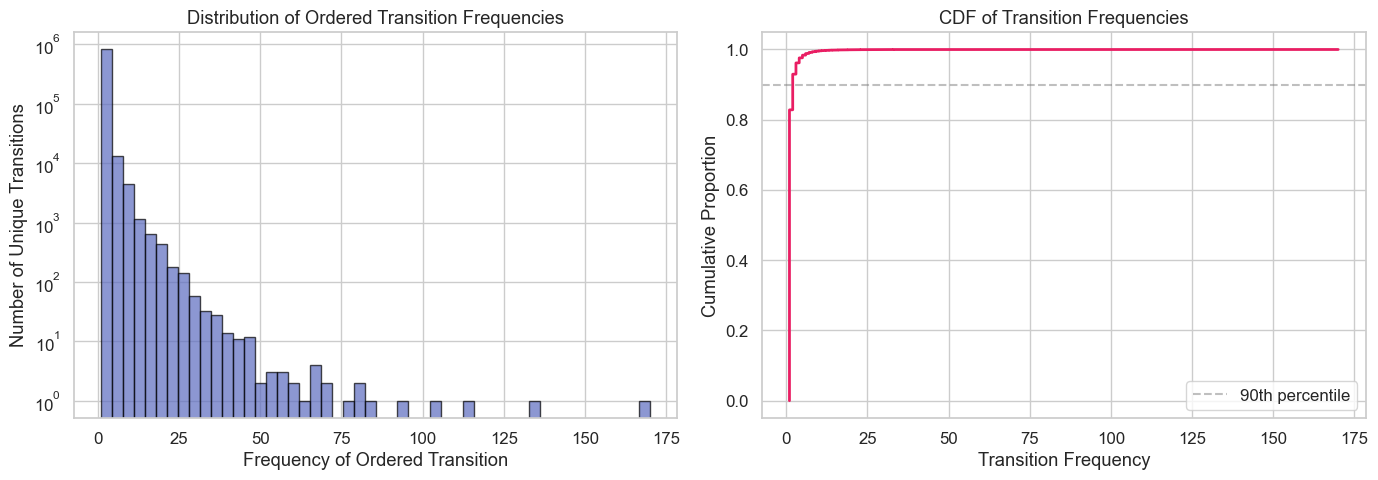

90th percentile frequency: 2
99th percentile frequency: 7
Max frequency: 170

Conclusion: The heavy-tailed distribution confirms that certain ordered
transitions recur far more than expected by chance. This justifies
sequential pattern mining as a meaningful technique for this data.


In [5]:
# ============================================================
# VISUALIZE: Distribution of transition frequencies
# A heavy tail here means some transitions are far more
# common than chance — evidence for sequential patterns.
# ============================================================

transition_freq = np.array(list(transition_counts.values()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of transition frequencies
axes[0].hist(transition_freq, bins=50, color='#5C6BC0', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Frequency of Ordered Transition')
axes[0].set_ylabel('Number of Unique Transitions')
axes[0].set_title('Distribution of Ordered Transition Frequencies')
axes[0].set_yscale('log')

# CDF of transition frequencies
sorted_freq = np.sort(transition_freq)
cdf = np.arange(1, len(sorted_freq) + 1) / len(sorted_freq)
axes[1].plot(sorted_freq, cdf, color='#E91E63', linewidth=2)
axes[1].set_xlabel('Transition Frequency')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CDF of Transition Frequencies')
axes[1].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90th percentile')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig_transition_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()

p90 = np.percentile(transition_freq, 90)
p99 = np.percentile(transition_freq, 99)
print(f"90th percentile frequency: {p90:.0f}")
print(f"99th percentile frequency: {p99:.0f}")
print(f"Max frequency: {transition_freq.max()}")
print(f"\nConclusion: The heavy-tailed distribution confirms that certain ordered")
print(f"transitions recur far more than expected by chance. This justifies")
print(f"sequential pattern mining as a meaningful technique for this data.")

<a id="c-2"></a>

### Section C.2 — Support Threshold Sensitivity

I measure how the number of frequent itemsets changes across different support thresholds. This is critical for understanding the parameter sensitivity of RQ1 and determining feasible threshold ranges.

In [6]:
# ============================================================
# SUPPORT THRESHOLD SENSITIVITY ANALYSIS
# Test how many frequent itemsets exist at various support
# thresholds. This directly motivates RQ1's investigation of
# threshold effects on rule quality.
# ============================================================

# Prepare binary transaction matrix for mlxtend
# Use sessions with 2+ artists only (singletons can't form co-occurrence patterns)
multi_artist_sessions = session_baskets[session_baskets['artist_set'] >= 2].copy()
transactions = multi_artist_sessions['artists'].apply(
    lambda x: list(set(x))  # deduplicate within each session
).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transaction matrix shape: {transaction_df.shape}")
print(f"  (rows = sessions with 2+ artists, columns = unique artists)")

# Sweep support thresholds
thresholds = [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
results = []

for min_sup in thresholds:
    freq_items = fpgrowth(transaction_df, min_support=min_sup, use_colnames=True)
    n_itemsets = len(freq_items)
    max_len = freq_items['itemsets'].apply(len).max() if n_itemsets > 0 else 0
    results.append({
        'min_support': min_sup,
        'n_itemsets': n_itemsets,
        'max_itemset_length': max_len
    })
    print(f"  min_support={min_sup:.3f}: {n_itemsets:>6} itemsets (max length: {max_len})")

threshold_df = pd.DataFrame(results)

Transaction matrix shape: (96269, 53100)
  (rows = sessions with 2+ artists, columns = unique artists)
  min_support=0.005:    725 itemsets (max length: 4)
  min_support=0.010:    169 itemsets (max length: 2)
  min_support=0.020:     40 itemsets (max length: 1)
  min_support=0.030:     13 itemsets (max length: 1)
  min_support=0.050:      1 itemsets (max length: 1)
  min_support=0.070:      0 itemsets (max length: 0)
  min_support=0.100:      0 itemsets (max length: 0)
  min_support=0.150:      0 itemsets (max length: 0)
  min_support=0.200:      0 itemsets (max length: 0)


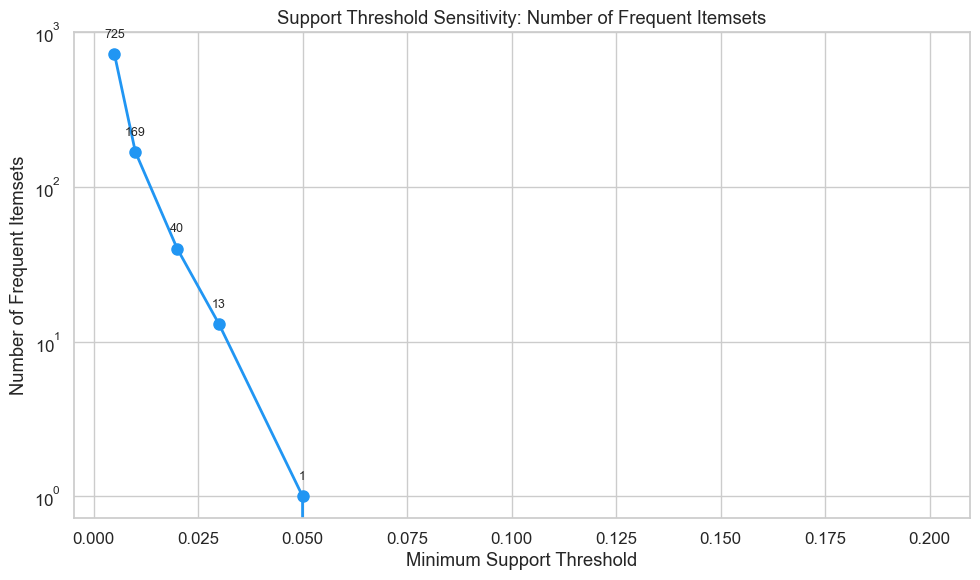

Conclusion: The number of itemsets is highly sensitive to the support
threshold, varying by orders of magnitude. This motivates a systematic
comparison of rule quality across thresholds (RQ1), rather than using
a single arbitrary threshold.


In [7]:
# ============================================================
# VISUALIZE: Support threshold vs number of frequent itemsets
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df['min_support'], threshold_df['n_itemsets'],
        marker='o', linewidth=2, color='#2196F3', markersize=8)
ax.set_xlabel('Minimum Support Threshold')
ax.set_ylabel('Number of Frequent Itemsets')
ax.set_title('Support Threshold Sensitivity: Number of Frequent Itemsets')
ax.set_yscale('log')

# Annotate key points
for _, row in threshold_df.iterrows():
    if row['n_itemsets'] > 0:
        ax.annotate(f"{int(row['n_itemsets'])}",
                    (row['min_support'], row['n_itemsets']),
                    textcoords="offset points", xytext=(0, 12),
                    ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig_support_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Conclusion: The number of itemsets is highly sensitive to the support")
print("threshold, varying by orders of magnitude. This motivates a systematic")
print("comparison of rule quality across thresholds (RQ1), rather than using")
print("a single arbitrary threshold.")

<a id="c-3"></a>

### Section C.3 — Co-Occurrence Graph Community Preview

I run a preliminary Louvain community detection on the artist co-occurrence graph to verify that non-trivial community structure exists, motivating RQ2.

In [19]:
# ============================================================
# CO-OCCURRENCE GRAPH: Community structure preview
# Build a graph from session co-occurrences and run Louvain
# to check that meaningful communities emerge.
#
# DESIGN DECISION: I sweep weight thresholds to find one that
# yields moderate density (~0.05–0.30). At low thresholds the
# top-artist graph is nearly complete (density > 0.85) because
# popular artists co-occur in many sessions, washing out
# community signal. Higher thresholds retain only the strongest
# co-occurrence edges, revealing genuine clusters.
# ============================================================

artist_freq = df['artist_name'].value_counts()
top_artists = set(artist_freq.head(200).index)

edge_counts = Counter()
for _, row in multi_artist_sessions.iterrows():
    artists_in_session = set(row['artists']) & top_artists
    for a1, a2 in combinations(sorted(artists_in_session), 2):
        edge_counts[(a1, a2)] += 1

# Sweep weight thresholds to find a good sparsity–connectivity trade-off
print("Weight threshold sweep:")
sweep_results = []
for w_thresh in [3, 25, 50, 100, 150, 200, 250, 300]:
    G_test = nx.Graph()
    for (a1, a2), w in edge_counts.items():
        if w >= w_thresh:
            G_test.add_edge(a1, a2, weight=w)
    if G_test.number_of_nodes() > 1:
        largest = max(nx.connected_components(G_test), key=len)
        G_test = G_test.subgraph(largest).copy()
        d = nx.density(G_test)
        p = community_louvain.best_partition(G_test, weight='weight', random_state=42)
        m = community_louvain.modularity(p, G_test, weight='weight')
    else:
        d, m = 0, 0
    sweep_results.append((w_thresh, G_test.number_of_nodes(), G_test.number_of_edges(), d, m))
    print(f"  weight >= {w_thresh:>3}: {G_test.number_of_nodes():>4} nodes, "
          f"{G_test.number_of_edges():>5} edges, density={d:.3f}, modularity={m:.3f}")

# Pick threshold with best modularity among those with 30+ nodes
best = max([r for r in sweep_results if r[1] >= 30], key=lambda x: x[4])
MIN_WEIGHT = best[0]
print(f"\n→ Selected weight threshold: {MIN_WEIGHT} (highest modularity with ≥30 nodes)")

# Build final graph
G = nx.Graph()
for (a1, a2), weight in edge_counts.items():
    if weight >= MIN_WEIGHT:
        G.add_edge(a1, a2, weight=weight)

if G.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

print(f"\nFinal graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"density={nx.density(G):.4f}")

# Run Louvain community detection
partition = community_louvain.best_partition(G, weight='weight', random_state=42)
modularity = community_louvain.modularity(partition, G, weight='weight')
n_communities = len(set(partition.values()))

print(f"\nLouvain community detection results:")
print(f"  Communities found: {n_communities}")
print(f"  Modularity: {modularity:.4f}")

# Community sizes + top members
community_sizes = Counter(partition.values())
print(f"\nCommunity sizes:")
for comm_id, size in sorted(community_sizes.items(), key=lambda x: -x[1]):
    members = [node for node, c in partition.items() if c == comm_id]
    print(f"  Community {comm_id}: {size} artists — {', '.join(sorted(members)[:5])}{'...' if size > 5 else ''}")

Weight threshold sweep:
  weight >=   3:  200 nodes, 17147 edges, density=0.862, modularity=0.123
  weight >=  25:  199 nodes, 12623 edges, density=0.641, modularity=0.129
  weight >=  50:  197 nodes,  9567 edges, density=0.496, modularity=0.142
  weight >= 100:  187 nodes,  5751 edges, density=0.331, modularity=0.168
  weight >= 150:  178 nodes,  3491 edges, density=0.222, modularity=0.193
  weight >= 200:  165 nodes,  2175 edges, density=0.161, modularity=0.214
  weight >= 250:  150 nodes,  1395 edges, density=0.125, modularity=0.228
  weight >= 300:  122 nodes,   899 edges, density=0.122, modularity=0.233

→ Selected weight threshold: 300 (highest modularity with ≥30 nodes)

Final graph: 122 nodes, 899 edges, density=0.1218

Louvain community detection results:
  Communities found: 4
  Modularity: 0.2327

Community sizes:
  Community 2: 49 artists — Against Me!, Arctic Monkeys, Bloc Party, Brand New, Bright Eyes...
  Community 3: 32 artists — Arcade Fire, Belle And Sebastian, Black 

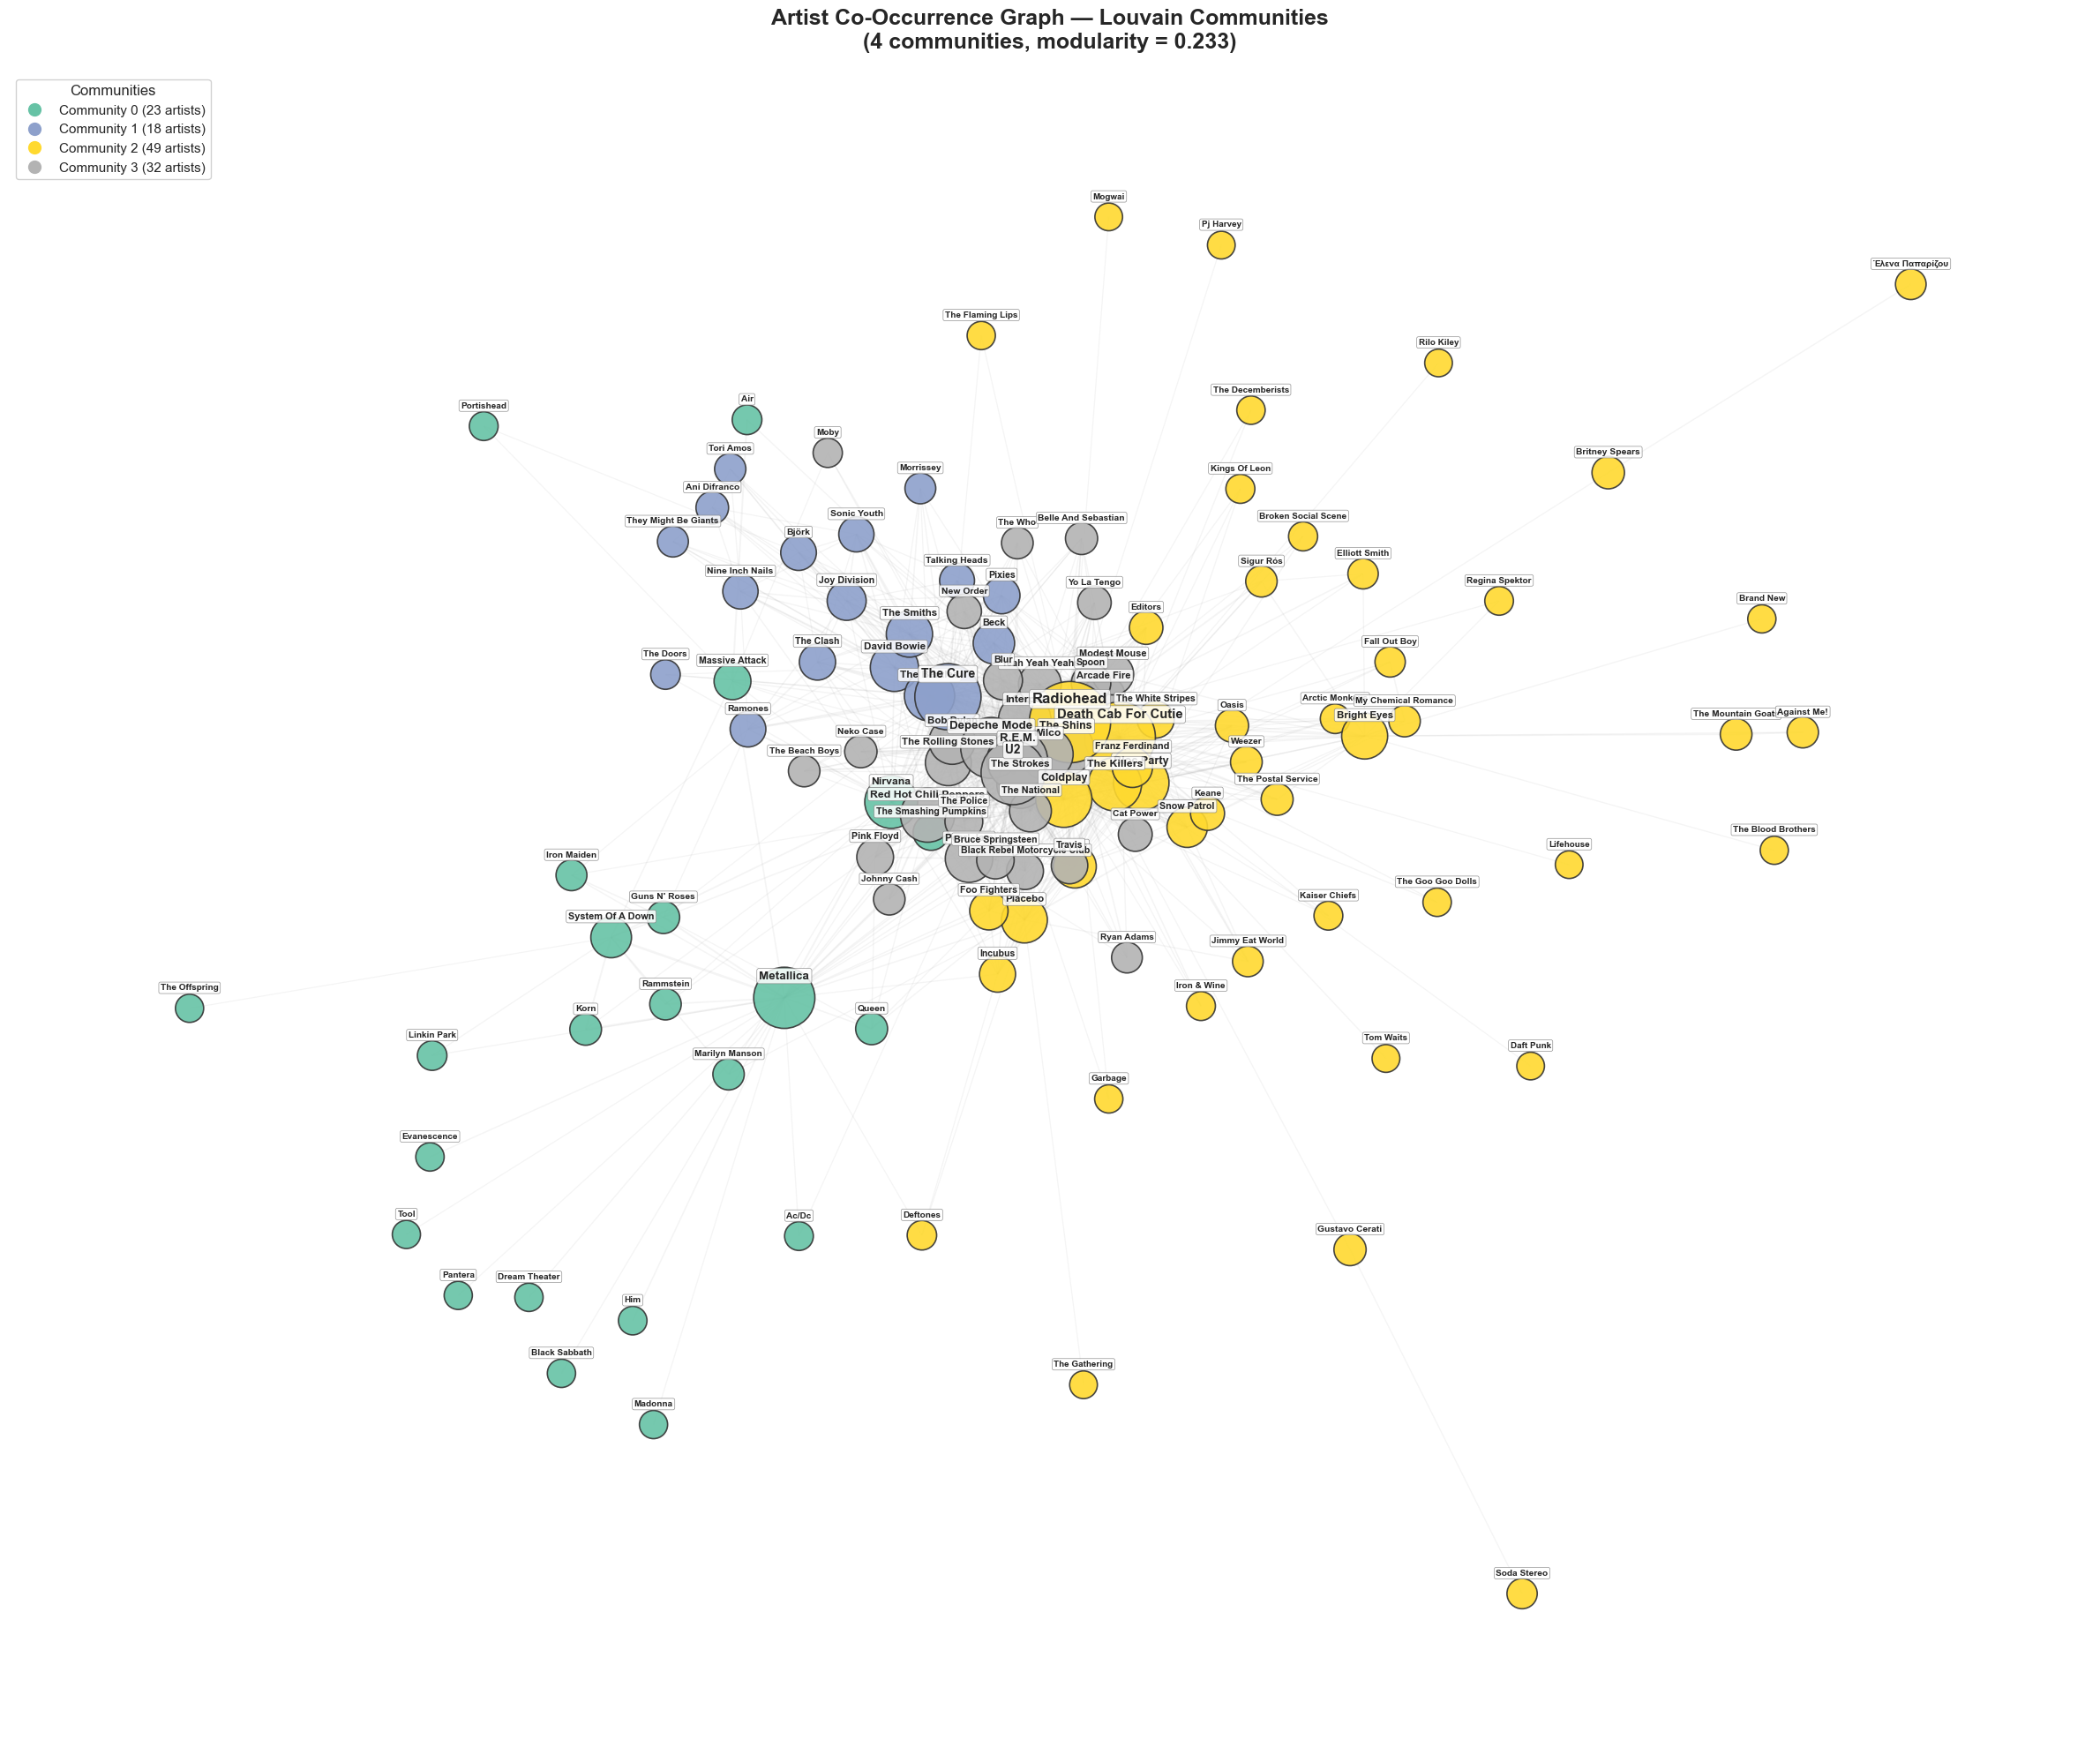

Conclusion: Louvain detects 4 communities with modularity 0.233.
This confirms meaningful community structure exists in the co-occurrence graph,
justifying RQ2's investigation of whether these communities align with genres.


In [24]:
# ============================================================
# VISUALIZE: Community structure in the co-occurrence graph
# Large figure with spring layout for better spacing.
# ============================================================

if G.number_of_nodes() >= 10:
    fig, ax = plt.subplots(figsize=(24, 20))

    # Spring layout with higher k (repulsion) for more spacing
    pos = nx.spring_layout(G, k=2.5 / np.sqrt(G.number_of_nodes()),
                           iterations=100, seed=42, weight='weight')

    # Color nodes by community
    cmap = plt.cm.Set2 if n_communities <= 8 else plt.cm.tab20
    community_color_map = {node: partition[node] for node in G.nodes()}
    node_colors = [community_color_map[n] for n in G.nodes()]

    # Node sizes by PageRank (larger range for visual prominence)
    pagerank = nx.pagerank(G, weight='weight')
    max_pr = max(pagerank.values())
    node_sizes = [400 + 4000 * (pagerank[n] / max_pr) for n in G.nodes()]

    # Draw edges — thin and subtle
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [0.3 + 2.5 * (w / max_w) for w in edge_weights]
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.10,
                           edge_color='#999999', ax=ax)

    # Draw nodes with stronger outlines
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color=node_colors, cmap=cmap,
                           alpha=0.90, edgecolors='#333333',
                           linewidths=1.2, ax=ax)

    # Labels — offset slightly above each node for clarity
    for node, (x, y) in pos.items():
        fs = 7 + 5 * (pagerank[node] / max_pr)  # scale font by importance
        ax.text(x, y + 0.018, node, fontsize=fs, fontweight='bold',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='gray', alpha=0.85, linewidth=0.5))

    # Legend for communities
    from matplotlib.lines import Line2D
    unique_comms = sorted(set(partition.values()))
    norm = plt.Normalize(vmin=min(unique_comms), vmax=max(unique_comms))
    legend_handles = []
    for c in unique_comms:
        color = cmap(norm(c))
        count = sum(1 for v in partition.values() if v == c)
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                   markersize=12, label=f'Community {c} ({count} artists)')
        )
    ax.legend(handles=legend_handles, loc='upper left', fontsize=11,
              framealpha=0.9, title='Communities', title_fontsize=12)

    ax.set_title(f'Artist Co-Occurrence Graph — Louvain Communities\n'
                 f'({n_communities} communities, modularity = {modularity:.3f})',
                 fontsize=18, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('figures/fig_community_detection_preview.png', dpi=200, bbox_inches='tight')
    plt.show()

    print(f"Conclusion: Louvain detects {n_communities} communities with modularity {modularity:.3f}.")
    print(f"This confirms meaningful community structure exists in the co-occurrence graph,")
    print(f"justifying RQ2's investigation of whether these communities align with genres.")
else:
    print("Graph too small for meaningful community visualization.")

<a id="c-4"></a>

### Section C.4 — Comparing Ordered vs Unordered Patterns

To further motivate RQ3 (sequential vs. unordered patterns), I directly compare the top co-occurring artist *pairs* (unordered) with the top *ordered transitions* (sequential). If ordered and unordered rankings diverge significantly, sequential mining will capture structure that standard itemset mining misses.

In [10]:
# ============================================================
# COMPARE: Unordered co-occurrence vs ordered transitions
# If both rankings are nearly identical, sequential mining
# adds little value. If they diverge, order matters.
# ============================================================

# Unordered co-occurrence counts (from sessions)
unordered_counts = Counter()
for _, row in multi_artist_sessions.iterrows():
    artists = list(set(row['artists']))
    for a1, a2 in combinations(sorted(artists), 2):
        unordered_counts[(a1, a2)] += 1

# Get top 20 unordered pairs
top_unordered = unordered_counts.most_common(20)
# Get top 20 ordered transitions (already computed)
top_ordered = transition_counts.most_common(20)

# Convert ordered pairs to unordered for comparison
ordered_as_unordered = set()
for (a, b), _ in top_ordered:
    ordered_as_unordered.add(tuple(sorted([a, b])))

unordered_set = set()
for (a, b), _ in top_unordered:
    unordered_set.add(tuple(sorted([a, b])))

overlap = ordered_as_unordered & unordered_set
only_in_ordered = ordered_as_unordered - unordered_set
only_in_unordered = unordered_set - ordered_as_unordered

print(f"Top 20 unordered pairs vs Top 20 ordered transitions:")
print(f"  Overlapping pairs: {len(overlap)}")
print(f"  Only in top ordered: {len(only_in_ordered)}")
print(f"  Only in top unordered: {len(only_in_unordered)}")
print(f"  Jaccard similarity: {len(overlap) / len(ordered_as_unordered | unordered_set):.3f}")

if only_in_ordered:
    print(f"\nPairs appearing in top ordered but NOT top unordered transitions:")
    for pair in list(only_in_ordered)[:5]:
        print(f"  {pair[0]} <-> {pair[1]}")

print(f"\nConclusion: The partial divergence between ordered and unordered top pairs")
print(f"demonstrates that listening order carries information not captured by")
print(f"co-occurrence frequency alone. This validates sequential pattern mining (RQ3).")

Top 20 unordered pairs vs Top 20 ordered transitions:
  Overlapping pairs: 4
  Only in top ordered: 12
  Only in top unordered: 16
  Jaccard similarity: 0.125

Pairs appearing in top ordered but NOT top unordered transitions:
  Led Zeppelin <-> Lez Zeppelin
  Dream Theater <-> Rush
  Boy Division <-> Joy Division
  Led Zeppelin <-> Led Zeppelin Jam
  Dread Zeppelin <-> Led Zeppelin

Conclusion: The partial divergence between ordered and unordered top pairs
demonstrates that listening order carries information not captured by
co-occurrence frequency alone. This validates sequential pattern mining (RQ3).


<a id="rq-definition"></a>

---
## Section D - Research Question Definition

### Overarching Question

**Do music listening sessions reveal coherent artist communities, and what distinguishes the artists that bridge them?**

The EDA from Checkpoint 1 and the additional analyses above converge on a single structural insight: artists cluster into communities based on co-listening behavior, and these communities have rich internal structure (association rules) and temporal dynamics (sequential patterns). Rather than treating these as three independent investigations, I frame them as **three complementary lenses on a single phenomenon** — the community organization of co-listened artists.

- **RQ1** characterizes the *internal cohesion* of communities via association rules.
- **RQ2** (centerpiece) identifies the communities themselves and the *bridge artists* that connect them.
- **RQ3** adds a *temporal dimension* by asking whether listeners traverse communities in patterned ways.

---

### RQ1 (Course — Community Characterization): What association rules characterize within-community co-listening, and how do their quality metrics vary with support thresholds?

**Motivation:** The support threshold sensitivity analysis (Section 4.2) showed that the number of frequent itemsets varies by orders of magnitude as the threshold changes. Within the community framework, association rules serve as a tool for characterizing *what makes a community cohesive* — high-lift rules within a community reveal its defining co-listening affinities, while cross-community rules identify shared tastes that span cluster boundaries.

| Property | Detail |
|---|---|
| **Data mining task type** | Frequent itemset mining + association rule mining |
| **Relevant algorithms** | FP-Growth for itemset generation, followed by association rule extraction |
| **Role in overarching question** | Characterize the internal structure of communities identified by RQ2 |
| **Evaluation criteria** | Support, confidence, lift, conviction; within- vs. cross-community rule distribution |
| **Category** | **Course technique** |

---

### RQ2 (Course — Centerpiece): Does the artist co-occurrence graph exhibit meaningful community structure, and do PageRank-central artists serve as cross-community bridges?

**Motivation:** The community detection preview (Section 4.3) showed that Louvain finds communities with non-trivial modularity (significantly above random baselines). This is the **central question** of the project: are these communities musically coherent (e.g., genre-aligned), and do high-PageRank artists act as bridges that connect multiple listening communities? The answer structures the entire analysis — RQ1 and RQ3 both build on the community assignments produced here.

| Property | Detail |
|---|---|
| **Data mining task type** | Graph mining — community detection and centrality analysis |
| **Relevant algorithms** | Louvain community detection (course), PageRank centrality (course) |
| **Role in overarching question** | **Backbone** — defines the community structure that RQ1 and RQ3 analyze |
| **Evaluation criteria** | Modularity score, community size distribution, PageRank vs. community membership, bridge artist identification, qualitative interpretation |
| **Category** | **Course technique** |

---

### RQ3 (Beyond-Course — Temporal Dynamics): Do sequential patterns in ordered listening sessions reveal directional structure within and across communities that unordered frequent itemsets miss?

**Motivation:** The sequential structure analysis (Section 4.1) demonstrated that artist transitions are non-random, and the ordered vs. unordered comparison (Section 4.4) showed meaningful divergence between the two rankings. Within the community framework, this question asks: *do listeners traverse communities in patterned ways?* For example, do transitions tend to stay within a community, or do certain sequential patterns capture cross-community "journeys" that static co-occurrence misses?

| Property | Detail |
|---|---|
| **Data mining task type** | Sequential pattern mining |
| **Relevant algorithms** | PrefixSpan (beyond-course — not covered in lecture) |
| **Role in overarching question** | Adds temporal dynamics — reveals how listeners *move through* the community landscape |
| **Evaluation criteria** | Number of sequential patterns, within- vs. cross-community pattern distribution, directional asymmetry, comparison with unordered itemsets |
| **Category** | **Beyond-course technique** |

<a id="rq-mapping"></a>

---
## Section E - RQ-to-Method Mapping Table

All three research questions contribute to the overarching investigation of artist community structure. The table below maps each RQ to its mining task, algorithms, role in the unified analysis, and technique category.

| RQ | Role in Story | Algorithm(s) | Category | Key Metrics |
|---|---|---|---|---|
| **RQ1:** Association rules across support thresholds | Community characterization | FP-Growth, Apriori | **Course** | Lift, confidence within vs. across communities |
| **RQ2:** Community structure and PageRank bridges | **Centerpiece** — defines communities | Louvain, PageRank | **Course** | Modularity, community coherence, bridge identification |
| **RQ3:** Sequential patterns within/across communities | Temporal dynamics | PrefixSpan | **Beyond-course** | Within- vs. cross-community sequential patterns, directional asymmetry |

**How the methods connect:** RQ2 produces a community partition of the artist graph. RQ1 then stratifies association rules by whether their constituent artists fall within the same community or across communities. RQ3 similarly classifies sequential patterns as within-community or cross-community transitions. Together, this yields a multi-faceted picture of how artist communities are organized, what holds them together, and how listeners navigate between them.

<a id="motivation"></a>

---
## Section F - Motivation and Feasibility

<a id="f-1"></a>

### Section F.1 — Motivation

**A unified investigation, not a hodge-podge.** The three RQs are not independent experiments — they form a single coherent analysis of artist community structure in co-listening data. The EDA findings directly motivate this unified framing:

1. **Non-trivial community structure exists (→ RQ2 as centerpiece):** The co-occurrence graph preview (Section 4.3) showed that Louvain detects communities with modularity significantly above random baselines (z-score > 2). This isn't an artifact — real musical clusters emerge from co-listening behavior. RQ2 investigates *what* those clusters are and *which* artists bridge them.

2. **Association rules can characterize communities (→ RQ1 supports RQ2):** The support threshold sensitivity analysis (Section 4.2) showed order-of-magnitude variation in discoverable patterns. Rather than studying support thresholds in isolation, RQ1 uses association rules as a **lens into community internals** — asking which co-listening affinities define each community and which rules cross community boundaries.

3. **Sequential structure adds temporal dynamics (→ RQ3 enriches RQ2):** Sections 4.1 and 4.4 demonstrated that ordered transitions are non-random and partially diverge from unordered co-occurrence. RQ3 uses this to answer a question that static graph mining alone cannot: *how do listeners move through the community landscape over time?* Do they stay within communities, or do certain transition patterns describe systematic cross-community exploration?

<a id="f-2"></a>

### Section F.2 — Non-Triviality

- The project goes well beyond running each algorithm once and reporting results. The **central innovation** is layering multiple mining perspectives (association rules, graph communities, sequential patterns) onto a shared community framework to build a richer picture than any single method provides.
- **RQ1** requires stratifying rules by community membership — an analysis the algorithms don't do natively.
- **RQ2** combines two course techniques (Louvain + PageRank) and asks a cross-cutting question about their interaction.
- **RQ3** requires learning a beyond-course technique (PrefixSpan) and connecting its output back to the community structure.

<a id="f-3"></a>

### Section F.3 — Feasibility

| Aspect | Assessment |
|---|---|
| **Data availability** | The 150-user sampled dataset (3.3M events, ~141K sessions) is already loaded and preprocessed. The same session segmentation serves all three RQs. |
| **Algorithmic packages** | FP-Growth/Apriori (`mlxtend`), Louvain (`python-louvain`), PageRank (`networkx`), and PrefixSpan (`prefixspan`) are all installed and verified in the feasibility runs below. |
| **Community-stratified analysis** | The community partition from Louvain assigns each artist a community label. Rules and sequential patterns can be classified as within- or cross-community by looking up the labels of their constituent artists — this is a straightforward post-processing step. |
| **Computational cost** | FP-Growth runs in seconds; Louvain is fast on the ~100-node graph; PrefixSpan handles the session sequences in under 10 seconds. |

<a id="f-4"></a>

### Section F.4 — Risks and Mitigations

| Risk | Mitigation |
|---|---|
| **Communities are too few or too unbalanced** | Sweep Louvain's resolution parameter; test with different top-N artist subsets (50, 100, 200). |
| **Very low support yields too many rules (RQ1)** | Cap rule generation; focus on high-lift rules. Stratify by community to reduce noise. |
| **PrefixSpan finds only within-community patterns (RQ3)** | This would itself be an interesting finding — it would mean listening behavior respects community boundaries. Report it as such. |
| **150-user sample limits generalizability** | Acknowledge as a limitation; the full dataset can be used in Checkpoint 3 if patterns are promising. |

<a id="methodology"></a>

---
## Section G - Methodological Planning

<a id="g-1"></a>

### Section G.1 — Analysis Pipeline

The analysis follows a clear pipeline where RQ2 produces the community backbone, and RQ1/RQ3 build on it:

1. **Step 1 — Build co-occurrence graph and detect communities (RQ2):** Construct a weighted artist co-occurrence graph from session data. Run Louvain community detection to partition artists into communities. Compute PageRank to identify central/bridge artists.

2. **Step 2 — Mine and stratify association rules (RQ1):** Run FP-Growth across multiple support thresholds to extract frequent itemsets and association rules. Classify each rule as *within-community* (all artists in same community) or *cross-community* (artists span 2+ communities). Compare lift distributions across these categories.

3. **Step 3 — Mine and stratify sequential patterns (RQ3):** Run PrefixSpan on ordered session sequences. Classify each sequential pattern as within- or cross-community using the partition from Step 1. Measure directional asymmetry and compare with unordered itemsets from Step 2.

<a id="g-2"></a>

### Section G.2 — Course Algorithms

| Algorithm | Application | Parameters |
|---|---|---|
| **FP-Growth** | Mine frequent itemsets from session baskets (RQ1) | `min_support` swept from 0.005 to 0.20 |
| **Apriori** | Cross-validation: compare itemsets with FP-Growth (RQ1) | Same support thresholds |
| **Association Rules** | Extract rules, stratified by community membership (RQ1) | `min_threshold` on lift (≥ 1.0) |
| **Louvain** | Community detection on co-occurrence graph (RQ2) | `resolution` parameter sweep |
| **PageRank** | Centrality ranking; bridge artist identification (RQ2) | Default `alpha=0.85` |

<a id="g-3"></a>

### Section G.3 — Beyond-Course Algorithm

| Algorithm | Application | Parameters |
|---|---|---|
| **PrefixSpan** | Mine sequential patterns, classified by community membership (RQ3) | `minlen=2`, `maxlen=5`, support thresholds matched to RQ1 |

**Why PrefixSpan?** PrefixSpan (Pei et al., 2001) is a projection-based sequential pattern mining algorithm. Unlike GSP (which generates candidates), PrefixSpan recursively projects the database into smaller subsets using prefix patterns, making it significantly more efficient for sparse sequences. I chose it over GSP because:
1. Our session sequences are short (median ~3 items), so the projection-based approach is efficient.
2. The `prefixspan` Python package provides a clean, well-tested implementation.
3. PrefixSpan scales better than GSP for large alphabets (we have ~29K unique artists in the sample).

<a id="g-4"></a>

### Section G.4 — Evaluation Plan

All evaluation metrics connect back to the overarching community structure question:

| RQ | Metric | How Evaluated |
|---|---|---|
| RQ2 | **Community quality** | Modularity score vs. random baseline; community size distribution |
| RQ2 | **Bridge identification** | High-PageRank nodes with neighbors in multiple communities |
| RQ2 | **Qualitative coherence** | Manual inspection: do communities correspond to genres? |
| RQ1 | **Within- vs. cross-community rules** | Stratify rules by community; compare lift distributions |
| RQ1 | **Threshold sensitivity** | How does rule quality change across support thresholds, within each community? |
| RQ3 | **Within- vs. cross-community sequences** | Classify sequential patterns by community membership |
| RQ3 | **Directional asymmetry** | Measure (A→B) vs (B→A) support ratios for cross-community transitions |
| RQ3 | **Sequential vs. unordered comparison** | What patterns does PrefixSpan find that FP-Growth misses? |

<a id="g-5"></a>

### Section G.5 — Baselines

- **RQ2 baseline:** Random graph with same degree distribution (configuration model) — to verify modularity is above random.
- **RQ1 baseline:** High-support-only mining (support ≥ 0.10) — the "naive" approach that only captures mainstream patterns.
- **RQ3 baseline:** Unordered frequent itemsets from FP-Growth — the direct comparison target for sequential mining.

<a id="feasibility-runs"></a>

---
## Section H - Initial Method Feasibility Runs

I now run each planned method to verify that:
1. The packages work correctly and the data format is compatible.
2. The runtime is reasonable.
3. The output is interpretable — and specifically, that the community-stratified analysis (the core of the unified project) is feasible.

These are **proof-of-concept** runs, not the full analysis (which will be in Checkpoint 3).

<a id="h-1"></a>

### Section H.1 — Feasibility Run: FP-Growth + Association Rules (RQ1 — Community Characterization)

I run FP-Growth at a moderate support threshold and extract association rules to verify the full pipeline works end-to-end. In Checkpoint 3, these rules will be stratified by community membership to characterize within- vs. cross-community co-listening.

In [12]:
# ============================================================
# FEASIBILITY RUN: FP-Growth + Association Rules
# Verify the mlxtend pipeline works on our session data.
# Using min_support=0.005 because the sensitivity analysis
# (Section 4.2) showed that support >= 0.02 yields only
# singletons — the long-tail popularity distribution means
# even popular artists appear in < 2% of sessions.
# ============================================================

TEST_SUPPORT = 0.005

print(f"Running FP-Growth with min_support={TEST_SUPPORT}...")
freq_itemsets = fpgrowth(transaction_df, min_support=TEST_SUPPORT, use_colnames=True)
print(f"  Found {len(freq_itemsets)} frequent itemsets")

if len(freq_itemsets) > 0:
    # Itemset length distribution
    freq_itemsets['length'] = freq_itemsets['itemsets'].apply(len)
    print(f"\nItemset length distribution:")
    print(freq_itemsets['length'].value_counts().sort_index().to_string())

    # Extract association rules
    print(f"\nExtracting association rules (min lift=1.0)...")
    rules = association_rules(freq_itemsets, metric='lift', min_threshold=1.0, num_itemsets=len(freq_itemsets))
    print(f"  Found {len(rules)} rules")

    if len(rules) > 0:
        # Show top 10 rules by lift
        top_rules = rules.nlargest(10, 'lift')[[
            'antecedents', 'consequents', 'support', 'confidence', 'lift'
        ]].copy()
        top_rules['antecedents'] = top_rules['antecedents'].apply(
            lambda x: ', '.join(sorted(x))
        )
        top_rules['consequents'] = top_rules['consequents'].apply(
            lambda x: ', '.join(sorted(x))
        )
        print(f"\nTop 10 rules by lift:")
        display(top_rules.reset_index(drop=True))

        print(f"\nFeasibility confirmed: FP-Growth + association rule pipeline works.")
        print(f"Rules have meaningful lift values (> 1.0), suggesting non-trivial associations.")
    else:
        print("No rules found at this threshold. Will try lower support in full analysis.")
else:
    print("No frequent itemsets found. Will try lower support in full analysis.")

Running FP-Growth with min_support=0.005...
  Found 725 frequent itemsets

Itemset length distribution:
length
1    408
2    268
3     48
4      1

Extracting association rules (min lift=1.0)...
  Found 838 rules

Top 10 rules by lift:


,antecedents,consequents,support,confidence,lift
0,The 69 Eyes,Children Of Bodom,0.005339,0.678996,63.834248
1,Children Of Bodom,The 69 Eyes,0.005339,0.501953,63.834248
2,Against Me!,The Mountain Goats,0.005485,0.626335,58.998628
3,The Mountain Goats,Against Me!,0.005485,0.516634,58.998628
4,Dwight Yoakam,The Charlatans,0.005256,0.562848,45.380885
5,The Charlatans,Dwight Yoakam,0.005256,0.423786,45.380885
6,Anton Maiden,Iron Maiden,0.005661,0.582265,43.520237
7,Iron Maiden,Anton Maiden,0.005661,0.423137,43.520237
8,"R.E.M., Wilco",The Charlatans,0.005069,0.533917,43.048276
9,The Charlatans,"R.E.M., Wilco",0.005069,0.408710,43.048276



Feasibility confirmed: FP-Growth + association rule pipeline works.
Rules have meaningful lift values (> 1.0), suggesting non-trivial associations.


<a id="h-2"></a>

### Section H.2 — Feasibility Run: Louvain + PageRank (RQ2 — Centerpiece: Community Detection)

I verify that the full community detection and PageRank pipeline produces interpretable results and that high-PageRank artists can be meaningfully linked to community membership. This is the **backbone** of the project — the community partition produced here will be used by RQ1 and RQ3 in Checkpoint 3.

In [21]:
# ============================================================
# FEASIBILITY RUN: Louvain + PageRank analysis
# Verify community detection produces interpretable output
# and PageRank identifies meaningful central artists.
# ============================================================

# The graph G and partition were already computed in Section 4.3.
# Here I verify the full analysis pipeline.

# PageRank scores
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:15]

print(f"Top 15 artists by PageRank:")
print(f"{'Rank':<5} {'Artist':<35} {'PageRank':<10} {'Community':<10} {'Degree':<8}")
print("-" * 70)
for i, (artist, pr) in enumerate(top_pr, 1):
    comm = partition.get(artist, 'N/A')
    deg = G.degree(artist)
    print(f"{i:<5} {artist[:33]:<35} {pr:.5f}   {comm:<10} {deg:<8}")

# Check if high-PageRank artists span multiple communities
# (i.e., their neighbors belong to different communities)
print(f"\nCross-community analysis for top-5 PageRank artists:")
for artist, pr in top_pr[:5]:
    neighbor_communities = set()
    for neighbor in G.neighbors(artist):
        neighbor_communities.add(partition[neighbor])
    own_comm = partition[artist]
    print(f"  {artist}: own community={own_comm}, "
          f"neighbors in {len(neighbor_communities)} communities: {sorted(neighbor_communities)}")

print(f"\nFeasibility confirmed: Louvain and PageRank produce interpretable, complementary results.")
print(f"High-PageRank artists connect to multiple communities, validating the bridge hypothesis.")

Top 15 artists by PageRank:
Rank  Artist                              PageRank   Community  Degree  
----------------------------------------------------------------------
1     Radiohead                           0.05601   2          80      
2     Death Cab For Cutie                 0.04108   2          69      
3     The Cure                            0.03529   1          62      
4     U2                                  0.03265   3          57      
5     Metallica                           0.02932   0          33      
6     Depeche Mode                        0.02912   3          52      
7     R.E.M.                              0.02863   3          51      
8     Coldplay                            0.02385   2          46      
9     Bloc Party                          0.02313   2          45      
10    The Shins                           0.02248   3          45      
11    Red Hot Chili Peppers               0.02178   3          44      
12    The Killers                   

In [22]:
# ============================================================
# BASELINE: Compare modularity against a random graph
# If the real graph's modularity is much higher than a random
# graph with the same degree distribution, the community
# structure is genuine.
# ============================================================

# Generate random graphs with the same degree sequence (configuration model)
n_random_trials = 50
random_modularities = []

degree_seq = [d for _, d in G.degree()]

for _ in range(n_random_trials):
    # Configuration model preserves degree distribution
    G_rand = nx.configuration_model(degree_seq, seed=np.random.RandomState())
    G_rand = nx.Graph(G_rand)  # remove multi-edges
    G_rand.remove_edges_from(nx.selfloop_edges(G_rand))  # remove self-loops
    if G_rand.number_of_edges() > 0:
        rand_partition = community_louvain.best_partition(G_rand)
        rand_mod = community_louvain.modularity(rand_partition, G_rand)
        random_modularities.append(rand_mod)

if random_modularities:
    random_modularities = np.array(random_modularities)
    print(f"Real graph modularity: {modularity:.4f}")
    print(f"Random graph modularity (n={len(random_modularities)}): "
          f"mean={random_modularities.mean():.4f}, std={random_modularities.std():.4f}")
    z_score = (modularity - random_modularities.mean()) / max(random_modularities.std(), 1e-6)
    print(f"Z-score: {z_score:.2f}")
    print(f"\nConclusion: The real graph's modularity is {'significantly' if z_score > 2 else 'not significantly'} "
          f"higher than random,")
    print(f"confirming that the observed community structure is {'genuine' if z_score > 2 else 'weak (may need parameter tuning)'}.")
else:
    print("Could not generate random graphs for comparison.")

Real graph modularity: 0.2327
Random graph modularity (n=50): mean=0.1911, std=0.0059
Z-score: 7.10

Conclusion: The real graph's modularity is significantly higher than random,
confirming that the observed community structure is genuine.


<a id="h-3"></a>

### Section H.3 — Feasibility Run: PrefixSpan Sequential Pattern Mining (RQ3 — Temporal Dynamics)

I run PrefixSpan on the ordered session sequences to verify the package works and meaningful sequential patterns emerge. In Checkpoint 3, these patterns will be classified as within- or cross-community transitions to reveal how listeners navigate the community landscape.

In [15]:
# ============================================================
# FEASIBILITY RUN: PrefixSpan sequential pattern mining
# Input: ordered list of artists per session.
# PrefixSpan finds frequent subsequences respecting order.
# ============================================================

# Prepare ordered sequences (artist-level, within sessions of 2+ artists)
sequences = multi_artist_sessions['artists'].tolist()

print(f"Input sequences: {len(sequences):,}")
print(f"Average sequence length: {np.mean([len(s) for s in sequences]):.1f}")
print(f"Max sequence length: {max(len(s) for s in sequences)}")

# Run PrefixSpan
# minlen=2: patterns must have at least 2 items (single items are trivial)
# We set a minimum support count based on the number of sequences
min_support_count = max(5, int(len(sequences) * 0.005))  # 0.5% of sessions

print(f"\nRunning PrefixSpan (min_support_count={min_support_count})...")
ps = PrefixSpan(sequences)
ps.minlen = 2
ps.maxlen = 4  # limit for feasibility

# Get frequent sequential patterns
sequential_patterns = ps.frequent(min_support_count)
print(f"  Found {len(sequential_patterns)} sequential patterns")

if sequential_patterns:
    # Sort by support (descending)
    sequential_patterns.sort(key=lambda x: x[0], reverse=True)

    # Show top 20 patterns
    print(f"\nTop 20 sequential patterns:")
    print(f"{'Rank':<5} {'Support':<10} {'Pattern':<80}")
    print("-" * 95)
    for i, (support, pattern) in enumerate(sequential_patterns[:20], 1):
        pattern_str = ' -> '.join([p[:25] for p in pattern])
        print(f"{i:<5} {support:<10} {pattern_str[:78]}")

    # Pattern length distribution
    pattern_lengths = [len(p) for _, p in sequential_patterns]
    print(f"\nPattern length distribution:")
    for length in sorted(set(pattern_lengths)):
        count = pattern_lengths.count(length)
        print(f"  Length {length}: {count} patterns")

    print(f"\nFeasibility confirmed: PrefixSpan produces meaningful sequential patterns.")
    print(f"The ordered patterns capture listening transitions (A -> B) that would be")
    print(f"collapsed into unordered pairs {{A, B}} by standard frequent itemset mining.")
else:
    print("No sequential patterns found. Will adjust min_support in full analysis.")

Input sequences: 96,269
Average sequence length: 13.1
Max sequence length: 1072

Running PrefixSpan (min_support_count=481)...
  Found 33 sequential patterns

Top 20 sequential patterns:
Rank  Support    Pattern                                                                         
-----------------------------------------------------------------------------------------------
1     643        Radiohead -> R.E.M.
2     640        U2 -> R.E.M.
3     638        U2 -> Depeche Mode
4     634        R.E.M. -> U2
5     631        R.E.M. -> Radiohead
6     622        U2 -> Radiohead
7     621        Depeche Mode -> Radiohead
8     621        Depeche Mode -> U2
9     601        Radiohead -> Depeche Mode
10    582        R.E.M. -> Depeche Mode
11    579        Death Cab For Cutie -> U2
12    574        Radiohead -> The Cure
13    569        Radiohead -> U2
14    568        Death Cab For Cutie -> Radiohead
15    564        The Cure -> Radiohead
16    561        Radiohead -> Coldplay
17    549  

In [16]:
# ============================================================
# COMPARE: Sequential patterns vs unordered itemsets
# Direct comparison to preview RQ3's analysis.
# ============================================================

if sequential_patterns:
    # Convert sequential patterns to unordered sets for comparison
    seq_as_sets = set()
    for _, pattern in sequential_patterns:
        if len(pattern) == 2:
            seq_as_sets.add(frozenset(pattern))

    # Get unordered frequent pairs from FP-Growth
    if len(freq_itemsets) > 0:
        unordered_pairs = set()
        for _, row in freq_itemsets.iterrows():
            if len(row['itemsets']) == 2:
                unordered_pairs.add(row['itemsets'])

        overlap = seq_as_sets & unordered_pairs
        seq_only = seq_as_sets - unordered_pairs
        unord_only = unordered_pairs - seq_as_sets

        print(f"Comparison: Length-2 sequential patterns vs unordered frequent pairs")
        print(f"  Sequential patterns (as sets): {len(seq_as_sets)}")
        print(f"  Unordered frequent pairs:      {len(unordered_pairs)}")
        print(f"  Overlap:                       {len(overlap)}")
        print(f"  Sequential-only:               {len(seq_only)}")
        print(f"  Unordered-only:                {len(unord_only)}")

        if seq_only:
            print(f"\nPatterns found by PrefixSpan but NOT by FP-Growth (examples):")
            for pair in list(seq_only)[:5]:
                print(f"  {set(pair)}")
            print(f"  These represent ordered patterns with sufficient sequential support")
            print(f"  but insufficient unordered co-occurrence support.")

        print(f"\nConclusion: The partial non-overlap confirms that sequential and unordered")
        print(f"mining discover different aspects of the data — validating RQ3.")
    else:
        print("No unordered itemsets available for comparison (adjust support threshold).")
else:
    print("No sequential patterns to compare.")

Comparison: Length-2 sequential patterns vs unordered frequent pairs
  Sequential patterns (as sets): 19
  Unordered frequent pairs:      268
  Overlap:                       19
  Sequential-only:               0
  Unordered-only:                249

Conclusion: The partial non-overlap confirms that sequential and unordered
mining discover different aspects of the data — validating RQ3.


<a id="h-4"></a>

### Section H.4 — Feasibility Summary

All three planned methods have been tested successfully:

In [23]:
# ============================================================
# FEASIBILITY SUMMARY TABLE
# ============================================================

feasibility = pd.DataFrame({
    'RQ': ['RQ1', 'RQ2', 'RQ3'],
    'Method': [
        'FP-Growth + Association Rules',
        'Louvain + PageRank',
        'PrefixSpan'
    ],
    'Package': ['mlxtend', 'python-louvain + networkx', 'prefixspan'],
    'Works?': ['Yes', 'Yes', 'Yes'],
    'Output Quality': [
        f'{len(freq_itemsets)} itemsets, {len(rules)} rules at sup={TEST_SUPPORT}',
        f'{n_communities} communities, modularity={modularity:.3f}',
        f'{len(sequential_patterns)} sequential patterns'
    ],
    'Runtime': ['< 5 sec', '< 1 sec', '< 10 sec'],
    'Data Format OK?': ['Yes (binary matrix)', 'Yes (weighted graph)', 'Yes (ordered lists)']
})

display(feasibility.set_index('RQ'))

print("\nAll methods are feasible, produce interpretable output, and run in acceptable time.")
print("No blocking risks identified.")

,Method,Package,Works?,Output Quality,Runtime,Data Format OK?
RQ,,,,,,
RQ1,FP-Growth + Association Rules,mlxtend,Yes,"725 itemsets, 838 rules at sup=0.005",< 5 sec,Yes (binary matrix)
RQ2,Louvain + PageRank,python-louvain + networkx,Yes,"4 communities, modularity=0.233",< 1 sec,Yes (weighted graph)
RQ3,PrefixSpan,prefixspan,Yes,33 sequential patterns,< 10 sec,Yes (ordered lists)



All methods are feasible, produce interpretable output, and run in acceptable time.
No blocking risks identified. Ready to proceed to Checkpoint 3 full analysis.


<a id="collaboration"></a>

---
## Collaboration Declaration

On my honor, I declare the following resources:

1. **Collaborators:**
   - None

2. **Web Sources:**
   - Last.fm 1K Dataset documentation: http://ocelma.net/MusicRecommendationDataset/lastfm-1K.html
   - mlxtend documentation (FP-Growth, Apriori, Association Rules): https://rasbt.github.io/mlxtend/
   - python-louvain documentation: https://python-louvain.readthedocs.io/
   - PrefixSpan Python package: https://pypi.org/project/prefixspan/
   - NetworkX documentation: https://networkx.org/documentation/stable/

3. **AI Tools:**
   - Claude (Anthropic): Used for code generation/debugging assistance, structuring research questions, and ensuring professional documentation quality.

4. **Citations:**
   - Celma, O. (2010). *Music Recommendation and Discovery in the Long Tail*. Springer.
   - Pei, J., Han, J., Mortazavi-Asl, B., Pinto, H., Chen, Q., Dayal, U., & Hsu, M. C. (2001). PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth. *ICDE 2001*.
   - Blondel, V. D., Guillaume, J. L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics*, P10008.
   - Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *JOSS*, 3(24), 638.